# Neural Networks from Scratch

This notebook implements neural networks from scratch in Python using NumPy.

It includes:
- binary classification
- hyperparameter tuning
- generalization to additional datasets
- comparison with scikit-learn
- regression
- multiclass classification

The goal is to understand how neural networks work at the implementation level rather than relying only on high-level libraries.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier, MLPRegressor

## Binary Classification: Core Functions

Below I implement the core functions for a two-layer neural network for binary classification:
- sigmoid activation
- parameter initialization
- forward propagation
- binary cross-entropy loss
- backward propagation
- training loop
- prediction
- accuracy scoring

In [19]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def initialize(X, units):
    np.random.seed(0)
    d = X.shape[1]
    W1 = np.random.rand(d, units)
    b1 = np.zeros((1, units))
    W2 = np.random.rand(units, 1)
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2


def forward_propagation(X, W1, b1, W2, b2):
    A1 = sigmoid(np.dot(X, W1) + b1)
    A2 = sigmoid(np.dot(A1, W2) + b2)
    return A1, A2


def cost(y, A2):
    m = y.shape[0]
    return (1 / m) * np.sum((-y * np.log(A2)) - (1 - y) * np.log(1 - A2))


def backward_propagation(X, y, W1, b1, W2, b2, A1, A2, alpha):
    m = y.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0) / m

    dZ1 = np.dot(dZ2, W2.T) * (A1 - (A1 ** 2))
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0) / m

    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2


def fit(X, y, units, max_iter, alpha, output_cost=False):
    W1, b1, W2, b2 = initialize(X, units)

    for i in range(max_iter):
        A1, A2 = forward_propagation(X, W1, b1, W2, b2)

        if output_cost and i % 100 == 0:
            print(f"Cost after iteration {i}: {cost(y, A2)}")

        W1, b1, W2, b2 = backward_propagation(X, y, W1, b1, W2, b2, A1, A2, alpha)

    return W1, b1, W2, b2


def predict(X, W1, b1, W2, b2):
    _, A2 = forward_propagation(X, W1, b1, W2, b2)
    return np.round(A2).astype(int)


def score(X, y, W1, b1, W2, b2):
    predicted = predict(X, W1, b1, W2, b2)
    return np.sum(y == predicted) / y.shape[0]

## Helper Function for Visualizing Decision Boundaries

In [20]:
def showDecisionBoundary(X, y, predict, W1=None, b1=None, W2=None, b2=None):
    xx, yy = np.meshgrid(
        np.arange(X[:, 0].min() - 0.15, X[:, 0].max() + 0.15, 0.01),
        np.arange(X[:, 1].min() - 0.15, X[:, 1].max() + 0.15, 0.01),
    )

    if W1 is None:
        Z = predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    else:
        Z = predict(np.c_[xx.ravel(), yy.ravel()], W1, b1, W2, b2).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40)
    plt.xticks([])
    plt.yticks([])
    plt.show()

## Binary Classification on Spiral Data

I trained the from-scratch neural network on a nonlinear spiral dataset to test whether the implementation can learn a complex decision boundary.

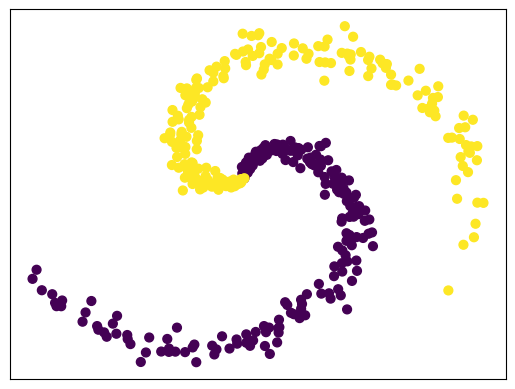

Cost after iteration 0: 0.8789501042818486
Cost after iteration 100: 0.4326769212137772
Cost after iteration 200: 0.39793024253989573
Cost after iteration 300: 0.39191532781107297
Cost after iteration 400: 0.38349236672740034
Cost after iteration 500: 0.3665358063365083
Cost after iteration 600: 0.341805510509007
Cost after iteration 700: 0.3157792031379734
Cost after iteration 800: 0.28999082181854036
Cost after iteration 900: 0.26516166632218047
Accuracy: 0.905


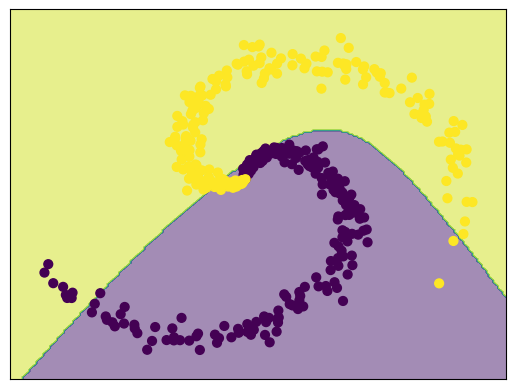

In [21]:
DATA = np.loadtxt("Spiral.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].reshape(-1, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=40)
plt.xticks([])
plt.yticks([])
plt.show()

W1, b1, W2, b2 = fit(X, y, units=5, max_iter=1000, alpha=1.0, output_cost=True)
spiral_accuracy = score(X, y, W1, b1, W2, b2)
print("Accuracy:", spiral_accuracy)

showDecisionBoundary(X, y, predict, W1, b1, W2, b2)

### Result

The model achieved approximately **90.5% accuracy** on the spiral dataset, showing that the from-scratch implementation can learn a nonlinear boundary reasonably well.

## Hyperparameter Tuning

I tested how model performance changed across:
- number of training iterations
- hidden layer size
- learning rate

This helped identify a better-performing model configuration for the spiral dataset.

In [22]:
maximum_iters = [500, 1000, 5000, 10000]

for iters in maximum_iters:
    W1, b1, W2, b2 = fit(X, y, units=5, max_iter=iters, alpha=1.0, output_cost=False)
    print(f"Accuracy with {iters} iterations: {score(X, y, W1, b1, W2, b2)}")

Accuracy with 500 iterations: 0.7475
Accuracy with 1000 iterations: 0.905
Accuracy with 5000 iterations: 0.9925
Accuracy with 10000 iterations: 0.995


In [23]:
num_units = [1, 2, 3, 4, 5, 10, 20]

for units in num_units:
    W1, b1, W2, b2 = fit(X, y, units=units, max_iter=1000, alpha=1.0, output_cost=False)
    print(f"Accuracy with {units} hidden units: {score(X, y, W1, b1, W2, b2)}")

Accuracy with 1 hidden units: 0.7225
Accuracy with 2 hidden units: 0.91
Accuracy with 3 hidden units: 0.9
Accuracy with 4 hidden units: 0.8925
Accuracy with 5 hidden units: 0.905
Accuracy with 10 hidden units: 0.9475
Accuracy with 20 hidden units: 0.955


In [24]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

for alpha in alphas:
    W1, b1, W2, b2 = fit(X, y, units=5, max_iter=1000, alpha=alpha, output_cost=False)
    print(f"Accuracy with alpha={alpha}: {score(X, y, W1, b1, W2, b2)}")

Accuracy with alpha=0.001: 0.5
Accuracy with alpha=0.01: 0.6975
Accuracy with alpha=0.1: 0.705
Accuracy with alpha=1.0: 0.905
Accuracy with alpha=10.0: 0.9925
Accuracy with alpha=100.0: 0.5


Tuned accuracy: 0.9975


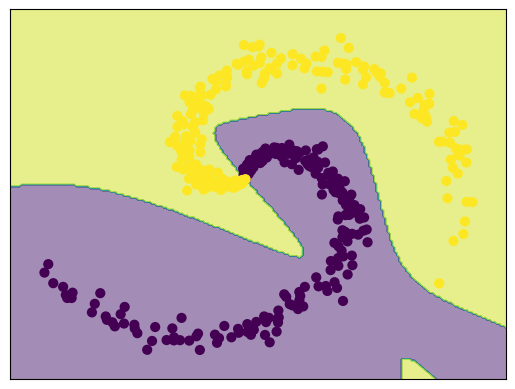

In [25]:
W1, b1, W2, b2 = fit(X, y, units=20, max_iter=10000, alpha=10.0, output_cost=False)
tuned_spiral_accuracy = score(X, y, W1, b1, W2, b2)
print("Tuned accuracy:", tuned_spiral_accuracy)

showDecisionBoundary(X, y, predict, W1, b1, W2, b2)

### Tuning Summary

Among the tested settings:
- more iterations improved performance substantially
- a larger hidden layer improved flexibility
- a learning rate of **10.0** performed best in this experiment

The tuned model achieved approximately **99.75% accuracy**.

## Generalization to Other Datasets

To evaluate robustness, I tested the same implementation on additional datasets with different decision boundaries.

Circles accuracy: 0.7525


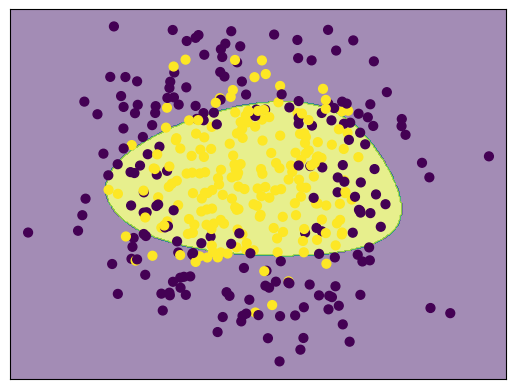

In [26]:
DATA = np.loadtxt("Circles.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].reshape(-1, 1)

W1, b1, W2, b2 = fit(X, y, units=5, max_iter=1000, alpha=1.0, output_cost=False)
circles_accuracy = score(X, y, W1, b1, W2, b2)
print("Circles accuracy:", circles_accuracy)

showDecisionBoundary(X, y, predict, W1, b1, W2, b2)

Random accuracy: 0.5275


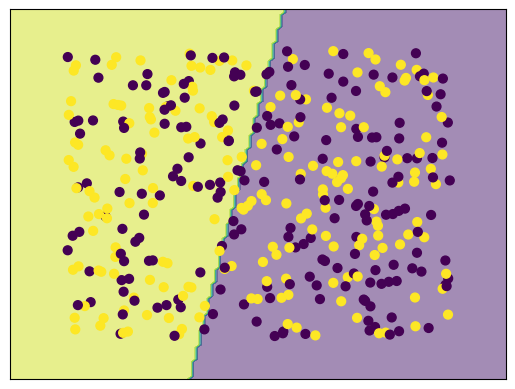

In [27]:
DATA = np.loadtxt("Random.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].reshape(-1, 1)

W1, b1, W2, b2 = fit(X, y, units=5, max_iter=1000, alpha=1.0, output_cost=False)
random_accuracy = score(X, y, W1, b1, W2, b2)
print("Random accuracy:", random_accuracy)

showDecisionBoundary(X, y, predict, W1, b1, W2, b2)

### Results

- Circles dataset: approximately **75.25%** accuracy  
- Random dataset: approximately **52.75%** accuracy  

The model performed better on structured nonlinear data than on highly noisy or weakly separable data.

## Comparison with scikit-learn

I compared the from-scratch implementation against scikit-learn's neural network model using the same spiral dataset.

scikit-learn accuracy: 0.805


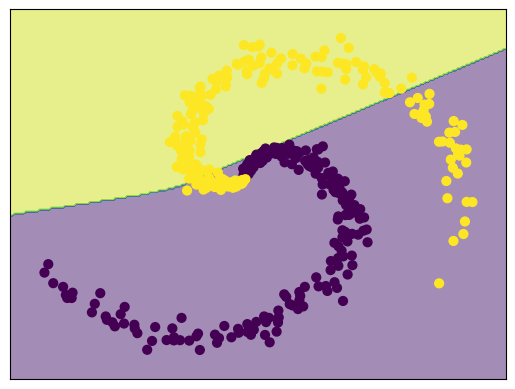

In [28]:
DATA = np.loadtxt("Spiral.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1]

sklearn_classifier = MLPClassifier(
    hidden_layer_sizes=(5,),
    max_iter=1000,
    learning_rate_init=1.0,
    random_state=0,
)
sklearn_classifier.fit(X, y)
print("scikit-learn accuracy:", sklearn_classifier.score(X, y))

showDecisionBoundary(X, y, sklearn_classifier.predict)

### Comparison

In this experiment, the from-scratch model performed better than the scikit-learn model under the tested settings (about **90.5% vs. 80.5% accuracy**).

## Training Dynamics: Cost over Iterations

To visualize optimization behavior, I modified the training function to return the cost at each iteration and plotted how the loss changed during gradient descent.

In [29]:
def fit_with_costs(X, y, units, max_iter, alpha, output_cost=False):
    W1, b1, W2, b2 = initialize(X, units)
    costs = []

    for i in range(max_iter):
        A1, A2 = forward_propagation(X, W1, b1, W2, b2)
        costs.append(cost(y, A2))

        if output_cost and i % 100 == 0:
            print(f"Cost after iteration {i}: {cost(y, A2)}")

        W1, b1, W2, b2 = backward_propagation(X, y, W1, b1, W2, b2, A1, A2, alpha)

    return W1, b1, W2, b2, costs

Cost after iteration 0: 0.8789501042818486
Cost after iteration 100: 0.4326769212137772
Cost after iteration 200: 0.39793024253989573
Cost after iteration 300: 0.39191532781107297
Cost after iteration 400: 0.38349236672740034
Cost after iteration 500: 0.3665358063365083
Cost after iteration 600: 0.341805510509007
Cost after iteration 700: 0.3157792031379734
Cost after iteration 800: 0.28999082181854036
Cost after iteration 900: 0.26516166632218047
Accuracy: 0.905


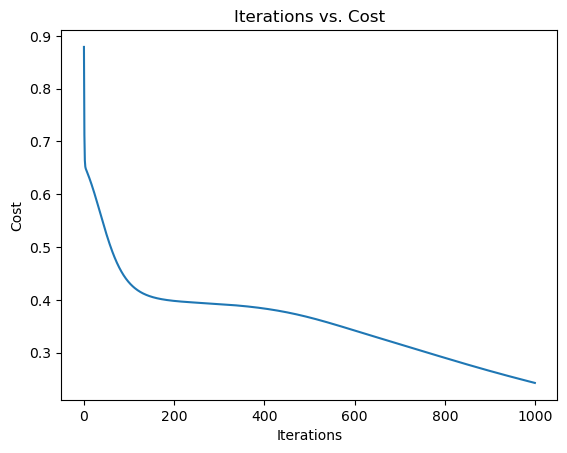

In [30]:
DATA = np.loadtxt("Spiral.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].reshape(-1, 1)

W1, b1, W2, b2, costs = fit_with_costs(X, y, units=5, max_iter=1000, alpha=1.0, output_cost=True)
print("Accuracy:", score(X, y, W1, b1, W2, b2))

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Iterations vs. Cost")
plt.show()

## Neural Network Regression

I adapted the same neural network framework for regression by replacing:
- the output activation
- the loss function
- the evaluation metric

The regression model was then compared with scikit-learn.

In [31]:
def forward_propagation(X, W1, b1, W2, b2):
    A1 = sigmoid(np.dot(X, W1) + b1)
    A2 = np.dot(A1, W2) + b2
    return A1, A2


def cost(y, A2):
    m = y.shape[0]
    return (1 / (2 * m)) * np.sum((y - A2) ** 2)


def predict(X, W1, b1, W2, b2):
    _, A2 = forward_propagation(X, W1, b1, W2, b2)
    return A2


def score(X, y, W1, b1, W2, b2):
    predicted = predict(X, W1, b1, W2, b2)
    return 1 - (np.sum((y - predicted) ** 2) / np.sum((y - np.mean(y)) ** 2))

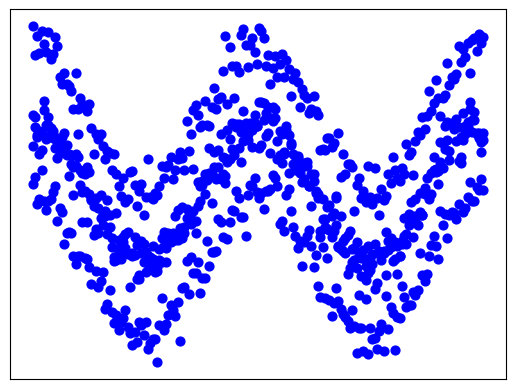

R^2 with 1 hidden units: 0.06909313944122009
R^2 with 5 hidden units: 0.13660161891178813
R^2 with 10 hidden units: 0.45900354876469496


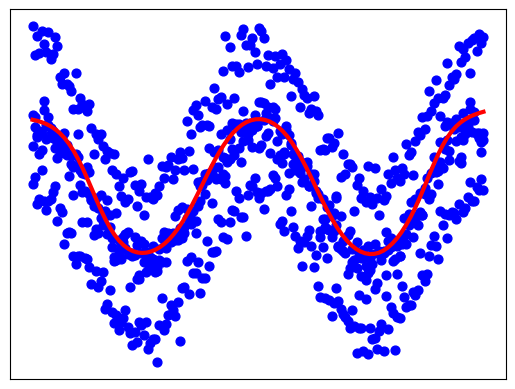

In [32]:
DATA = np.loadtxt("w.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].reshape(-1, 1)

plt.scatter(X, y, c="b", s=40)
plt.xticks([])
plt.yticks([])
plt.show()

for units in [1, 5, 10]:
    W1, b1, W2, b2 = fit(X, y, units=units, max_iter=5000, alpha=1.0, output_cost=False)
    print(f"R^2 with {units} hidden units: {score(X, y, W1, b1, W2, b2)}")

plt.scatter(X, y, c="b", s=40)
plt.xticks([])
plt.yticks([])
regression_line = np.linspace(np.min(X), np.max(X), 100).reshape(-1, 1)
plt.plot(regression_line, predict(regression_line, W1, b1, W2, b2), c="r", linewidth=3)
plt.show()

scikit-learn R^2: 0.45648533411800407


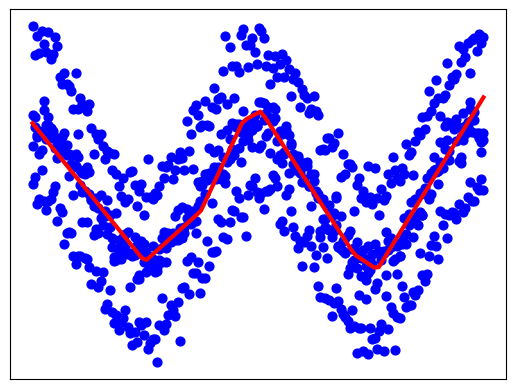

In [33]:
DATA = np.loadtxt("w.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].flatten()

sklearn_regressor = MLPRegressor(
    hidden_layer_sizes=(10,),
    max_iter=5000,
    learning_rate_init=0.01,
    random_state=0,
)
sklearn_regressor.fit(X, y)
print("scikit-learn R^2:", sklearn_regressor.score(X, y))

plt.scatter(X, y, c="b", s=40)
plt.xticks([])
plt.yticks([])
regression_line = np.linspace(np.min(X), np.max(X), 100).reshape(-1, 1)
plt.plot(regression_line, sklearn_regressor.predict(regression_line), c="r", linewidth=3)
plt.show()

### Regression Results

The from-scratch neural network achieved an **R² of about 0.459**, while the scikit-learn regressor achieved a very similar **R² of about 0.456**.

## Multiclass Classification

Finally, I extended the network to multiclass classification by:
- replacing sigmoid output with softmax
- modifying the loss function
- updating prediction logic to return the highest-probability class

In [34]:
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)


def initialize(X, units, k):
    np.random.seed(0)
    d = X.shape[1]
    W1 = np.random.rand(d, units)
    b1 = np.zeros((1, units))
    W2 = np.random.rand(units, k)
    b2 = np.zeros((1, k))
    return W1, b1, W2, b2


def forward_propagation(X, W1, b1, W2, b2):
    A1 = sigmoid(np.dot(X, W1) + b1)
    A2 = softmax(np.dot(A1, W2) + b2)
    return A1, A2


def cost(y, A2):
    y_onehot = np.eye(np.max(y) + 1)[y]
    return np.sum(-np.sum(y_onehot * np.log(A2), axis=1)) / y.shape[0]


def backward_propagation(X, y, W1, b1, W2, b2, A1, A2, alpha):
    m = y.shape[0]

    dZ2 = A2.copy()
    dZ2[np.arange(m), y] -= 1

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0) / m

    dZ1 = np.dot(dZ2, W2.T) * (A1 - (A1 ** 2))
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0) / m

    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2


def fit(X, y, units, max_iter, alpha, output_cost=False):
    W1, b1, W2, b2 = initialize(X, units, np.max(y) + 1)

    for i in range(max_iter):
        A1, A2 = forward_propagation(X, W1, b1, W2, b2)

        if output_cost and i % 100 == 0:
            print(f"Cost after iteration {i}: {cost(y, A2)}")

        W1, b1, W2, b2 = backward_propagation(X, y, W1, b1, W2, b2, A1, A2, alpha)

    return W1, b1, W2, b2


def predict(X, W1, b1, W2, b2):
    _, A2 = forward_propagation(X, W1, b1, W2, b2)
    return np.argmax(A2, axis=1)


def score(X, y, W1, b1, W2, b2):
    predicted = predict(X, W1, b1, W2, b2)
    return np.sum(y == predicted) / y.shape[0]

Initial multiclass accuracy: 0.8366666666666667


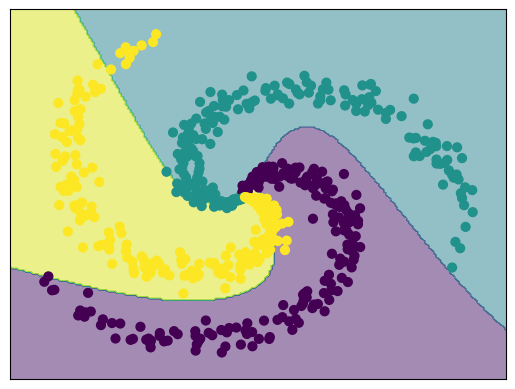

In [35]:
DATA = np.loadtxt("Spiral3.csv", delimiter=",")
X = DATA[:, :-1]
y = DATA[:, -1].astype(int)

W1, b1, W2, b2 = fit(X, y, units=5, max_iter=1000, alpha=1.0, output_cost=False)
multiclass_accuracy = score(X, y, W1, b1, W2, b2)
print("Initial multiclass accuracy:", multiclass_accuracy)

showDecisionBoundary(X, y, predict, W1, b1, W2, b2)

In [36]:
for iters in [500, 1000, 5000, 10000, 12000, 15000]:
    W1, b1, W2, b2 = fit(X, y, units=5, max_iter=iters, alpha=1.0, output_cost=False)
    print(f"Accuracy with {iters} iterations: {score(X, y, W1, b1, W2, b2)}")

for units in [1, 2, 3, 4, 5, 10, 13, 14, 15, 16, 17, 20, 23, 25, 28, 30]:
    W1, b1, W2, b2 = fit(X, y, units=units, max_iter=1000, alpha=1.0, output_cost=False)
    print(f"Accuracy with {units} hidden units: {score(X, y, W1, b1, W2, b2)}")

for alpha in [0.001, 0.01, 0.1, 0.3, 0.7, 0.9, 1.0, 1.5, 3.0, 5.0, 5.5, 6.0, 6.5, 8.0, 10.0, 100.0]:
    W1, b1, W2, b2 = fit(X, y, units=5, max_iter=1000, alpha=alpha, output_cost=False)
    print(f"Accuracy with alpha={alpha}: {score(X, y, W1, b1, W2, b2)}")

Accuracy with 500 iterations: 0.6083333333333333
Accuracy with 1000 iterations: 0.8366666666666667
Accuracy with 5000 iterations: 0.985
Accuracy with 10000 iterations: 0.985
Accuracy with 12000 iterations: 0.985
Accuracy with 15000 iterations: 0.985
Accuracy with 1 hidden units: 0.505
Accuracy with 2 hidden units: 0.6533333333333333
Accuracy with 3 hidden units: 0.6383333333333333
Accuracy with 4 hidden units: 0.6933333333333334
Accuracy with 5 hidden units: 0.8366666666666667
Accuracy with 10 hidden units: 0.835
Accuracy with 13 hidden units: 0.7983333333333333
Accuracy with 14 hidden units: 0.83
Accuracy with 15 hidden units: 0.9016666666666666
Accuracy with 16 hidden units: 0.84
Accuracy with 17 hidden units: 0.775
Accuracy with 20 hidden units: 0.8866666666666667
Accuracy with 23 hidden units: 0.83
Accuracy with 25 hidden units: 0.8383333333333334
Accuracy with 28 hidden units: 0.8083333333333333
Accuracy with 30 hidden units: 0.765
Accuracy with alpha=0.001: 0.41
Accuracy with alp

Tuned multiclass accuracy: 0.9966666666666667


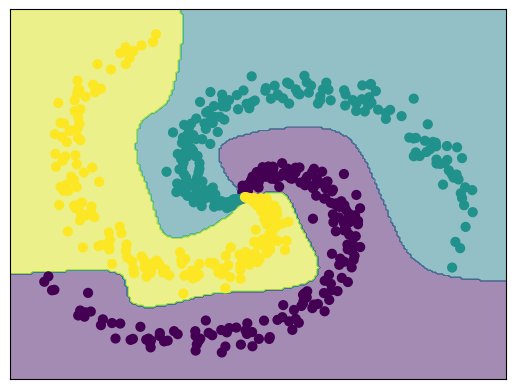

In [37]:
W1, b1, W2, b2 = fit(X, y, units=15, max_iter=5000, alpha=5.0, output_cost=False)
tuned_multiclass_accuracy = score(X, y, W1, b1, W2, b2)
print("Tuned multiclass accuracy:", tuned_multiclass_accuracy)

showDecisionBoundary(X, y, predict, W1, b1, W2, b2)

scikit-learn accuracy with 100 iterations: 0.49166666666666664
scikit-learn accuracy with 1000 iterations: 0.49166666666666664
scikit-learn accuracy with 5000 iterations: 0.49166666666666664
scikit-learn accuracy with 10000 iterations: 0.49166666666666664
scikit-learn accuracy with 12000 iterations: 0.49166666666666664
scikit-learn accuracy with 20000 iterations: 0.49166666666666664
scikit-learn accuracy with 25000 iterations: 0.49166666666666664
scikit-learn accuracy with 4 hidden units: 0.3333333333333333
scikit-learn accuracy with 5 hidden units: 0.49166666666666664
scikit-learn accuracy with 10 hidden units: 0.84
scikit-learn accuracy with 13 hidden units: 0.875
scikit-learn accuracy with 14 hidden units: 0.93
scikit-learn accuracy with 15 hidden units: 0.9466666666666667
scikit-learn accuracy with 16 hidden units: 0.8566666666666667
scikit-learn accuracy with 17 hidden units: 0.9483333333333334
scikit-learn accuracy with 20 hidden units: 0.785
scikit-learn accuracy with alpha=0.25

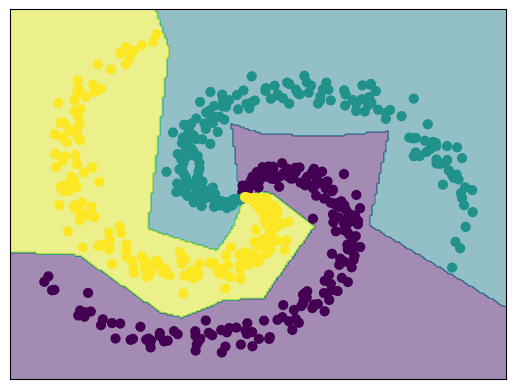

In [38]:
for iters in [100, 1000, 5000, 10000, 12000, 20000, 25000]:
    model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=iters, learning_rate_init=1.0, random_state=0)
    model.fit(X, y)
    print(f"scikit-learn accuracy with {iters} iterations: {model.score(X, y)}")

for units in [4, 5, 10, 13, 14, 15, 16, 17, 20]:
    model = MLPClassifier(hidden_layer_sizes=(units,), max_iter=1000, learning_rate_init=1.0, random_state=0)
    model.fit(X, y)
    print(f"scikit-learn accuracy with {units} hidden units: {model.score(X, y)}")

for alpha in [0.25, 0.3, 0.35, 0.4, 0.5, 0.7, 1.0, 1.5, 3.0, 5.0, 5.5, 6.0]:
    model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, learning_rate_init=alpha, random_state=0)
    model.fit(X, y)
    print(f"scikit-learn accuracy with alpha={alpha}: {model.score(X, y)}")

sklearn_multiclass = MLPClassifier(hidden_layer_sizes=(13,), max_iter=5000, learning_rate_init=0.4, random_state=0)
sklearn_multiclass.fit(X, y)
print("Best scikit-learn multiclass accuracy:", sklearn_multiclass.score(X, y))

showDecisionBoundary(X, y, sklearn_multiclass.predict)

### Multiclass Result

Both the from-scratch and scikit-learn models achieved approximately **99.67% accuracy** in this experiment, though with different hyperparameter settings.

## Final Takeaways

This notebook demonstrates how neural networks can be implemented from scratch using NumPy for multiple supervised learning settings:
- binary classification
- regression
- multiclass classification

The project also shows how hyperparameters affect performance and how a custom implementation compares with scikit-learn.